In [2]:
import h5py
from matplotlib import pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import  numpy as np
import torch
import os
import pickle
from dtw import dtw
import pandas as pd

LOGIT_TO_PHONEME = [
    'BLANK',
    'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B',  'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K',
    'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH',
    'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH',
    ' | ',
]

LOGIT_DICT = {i: ph for i, ph in enumerate(LOGIT_TO_PHONEME)}


def load_h5py_file(file_path):
    data = {
        'neural_features': [],
        'n_time_steps': [],
        'seq_class_ids': [],
        'seq_len': [],
        'transcriptions': [],
        'sentence_label': [],
        'session': [],
        'block_num': [],
        'trial_num': [],
    }
    # Open the hdf5 file for that day
    with h5py.File(file_path, 'r') as f:

        keys = list(f.keys())

        # For each trial in the selected trials in that day
        for key in keys:
            g = f[key]

            neural_features = g['input_features'][:]
            n_time_steps = g.attrs['n_time_steps']
            seq_class_ids = g['seq_class_ids'][:] if 'seq_class_ids' in g else None
            seq_len = g.attrs['seq_len'] if 'seq_len' in g.attrs else None
            transcription = g['transcription'][:] if 'transcription' in g else None
            sentence_label = g.attrs['sentence_label'][:] if 'sentence_label' in g.attrs else None
            session = g.attrs['session']
            block_num = g.attrs['block_num']
            trial_num = g.attrs['trial_num']
            data['neural_features'].append(neural_features)
            data['n_time_steps'].append(n_time_steps)
            data['seq_class_ids'].append(seq_class_ids)
            data['seq_len'].append(seq_len)
            data['transcriptions'].append(transcription)
            data['sentence_label'].append(sentence_label)
            data['session'].append(session)
            data['block_num'].append(block_num)
            data['trial_num'].append(trial_num)
    return data

#!ls ../data/brain/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11

data = load_h5py_file('data/t15_copyTask_neuralData/hdf5_data_final/t15.2023.08.11/data_train.hdf5')

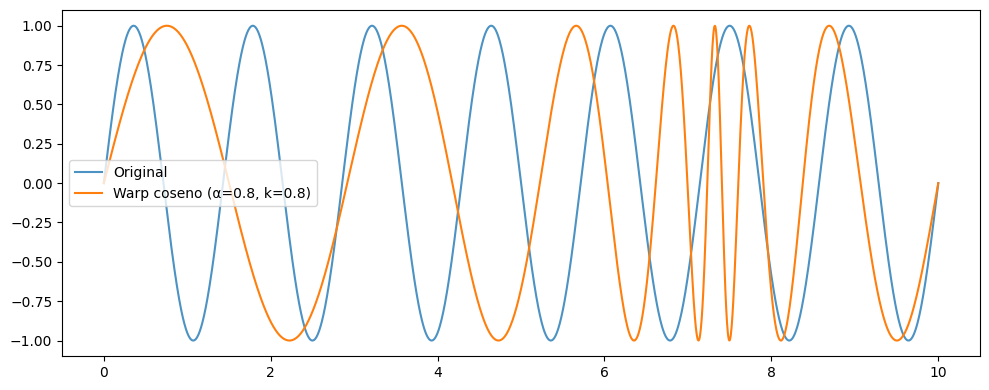

In [3]:
import numpy as np
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid

def time_warp_from_speed(x, T, speed, kind_signal="cubic"):
    """
    Deforma 'x' en el tiempo usando un perfil de velocidad 'speed' y
    mantiene la misma duración T (renormalizando tau).
    
    Parámetros
    ----------
    x : array (N,)
        Señal original (muestra uniforme en [0, T]).
    T : float
        Duración total (segundos).
    speed : callable o array (N,)
        Perfil s(t) > 0. Si es callable, se evalúa como s(t) en la malla.
        Si es array, debe ser de largo N y corresponder a s(t_i).
    kind_signal : str
        Tipo de interpolación para la señal ("linear", "cubic", etc.)

    Devuelve
    --------
    t : array (N,)         # malla destino (idéntica a la original)
    x_warp : array (N,)    # señal deformada con la misma longitud
    t_orig : array (N,)    # tiempo original que corresponde a cada t
    s : array (N,)         # perfil de velocidad evaluado en t
    tau : array (N,)       # mapeo acumulado renormalizado
    """
    N = len(x)
    t = np.linspace(0, T, N)

    # 1) Obtener s(t) desde 'speed'
    if callable(speed):
        s = np.asarray(speed(t), dtype=float)
    else:
        s = np.asarray(speed, dtype=float)
        if s.shape != (N,):
            raise ValueError("Si 'speed' es array, debe tener la misma longitud que x.")
    
    if np.min(s) <= 0:
        raise ValueError("El perfil de velocidad debe cumplir s(t) > 0 en todo el dominio.")

    # 2) τ(t) = ∫ s(u) du (acumulada desde 0)
    tau = cumulative_trapezoid(s, t, initial=0.0)

    # 3) Renormalizar para que tau[-1] sea EXACTAMENTE T
    tau_end = tau[-1]
    if tau_end <= 0:
        raise RuntimeError("τ(T) no válido; revisa el perfil de velocidad.")
    tau = tau * (T / tau_end)   # ahora tau[-1] == T (numéricamente)

    # 4) Interpoladores
    # Señal x(t)
    x_of_t = interp1d(t, x, kind=kind_signal, fill_value="extrapolate", assume_sorted=True)
    # Inversa τ^{-1}: de tau -> t
    t_of_tau = interp1d(tau, t, kind="linear", assume_sorted=True,
                        bounds_error=False, fill_value=(t[0], t[-1]))

    # 5) Remuestrear sobre la misma malla 't' (y clipear por seguridad)
    t_query = np.clip(t, tau[0], tau[-1])  # [0, T]
    t_orig = t_of_tau(t_query)
    x_warp = x_of_t(t_orig)

    return t, x_warp, t_orig, s, tau

import matplotlib.pyplot as plt

# Señal de prueba
T = 10.0
N = 2000
t = np.linspace(0, T, N)
x = np.sin(2*np.pi*0.7*t) 

# Defino el perfil s(t) como función: s(t)=1+alpha*cos(2π k t/T)
alpha, k = 0.8, 0.8 # rango de 0.2 - 5
def cosine_speed(tt):
    return  1 +  alpha*np.cos(2*np.pi*k * tt / T)

t, x_warp, t_orig, s, tau = time_warp_from_speed(x, T, cosine_speed)

plt.figure(figsize=(10,4))
plt.plot(t, x, label="Original", alpha=0.8)
plt.plot(t, x_warp, label=f"Warp coseno (α={alpha}, k={k})")
plt.legend(); plt.tight_layout(); plt.show()

In [4]:
import torch

def torch_interp1d(x, xp, fp):
    """
    Linear interpolation in torch.
    x: query points (...,)
    xp: x-coordinates of data points (T,)
    fp: values at xp (T,)
    Returns: interpolated values (...,)
    """
    # Ensure 1D
    xp = xp.flatten()
    fp = fp.flatten()
    x = x.flatten()

    # clip to domain
    x = torch.clamp(x, xp[0], xp[-1])

    # find right indices
    idx = torch.searchsorted(xp, x) - 1
    idx = torch.clamp(idx, 0, len(xp)-2)

    x0, x1 = xp[idx], xp[idx+1]
    y0, y1 = fp[idx], fp[idx+1]

    slope = (y1 - y0) / (x1 - x0)
    y = y0 + slope * (x - x0)
    return y.reshape_as(x)


def torch_cumtrapz(y, x):
    """
    Torch version of scipy.integrate.cumulative_trapezoid with initial=0.0
    y: (T,)
    x: (T,)
    """
    dx = x[1:] - x[:-1]
    avg = (y[1:] + y[:-1]) * 0.5
    area = avg * dx
    cumsum = torch.cumsum(area, dim=0)
    return torch.cat([torch.zeros(1, device=y.device, dtype=y.dtype), cumsum])


def _time_warp_from_speed_1d_torch(x, t, speed_fn):
    """
    Torch-only version of time-warp.
    x: (T,)
    t: (T,)
    speed_fn: callable(tt)->(T,) returns s(t)
    Returns: x_warp, t_orig, s, tau
    """
    s = speed_fn(t)
    if s.shape != t.shape:
        raise ValueError("El perfil de velocidad debe tener la misma forma que t.")
    if torch.min(s) <= 0:
        raise ValueError("s(t) debe ser > 0 en todo el dominio.")

    tau = torch_cumtrapz(s, t)
    T_final = t[-1] - t[0]
    tau_end = tau[-1]
    if tau_end <= 0:
        raise RuntimeError("τ(T) no válido; revisa s(t).")
    tau = tau * (T_final / tau_end)

    # maps
    t_of_tau = lambda tauq: torch_interp1d(tauq, tau, t)
    x_of_t   = lambda tq: torch_interp1d(tq, t, x)

    t_query = torch.clamp(t, tau[0], tau[-1])
    t_orig  = t_of_tau(t_query)
    x_warp  = x_of_t(t_orig)
    return x_warp, t_orig, s, tau


def augment_time_warp_cosine_torch(
    neural_features,   # torch.Tensor (B,C,T) o (C,T)
    dt,
    alpha=0.6,
    k=None,
    k_range=(1, 5),
    per_channel_same_warp=True
):
    """
    Aplica time-warp coseno s(t)=1+alpha*cos(2π k t / Tdur) conservando longitud.
    Todo implementado en torch.
    """
    if not isinstance(neural_features, torch.Tensor):
        raise ValueError("Input debe ser torch.Tensor")

    orig_device = neural_features.device
    orig_dtype  = neural_features.dtype

    X = neural_features.to(torch.float32)

    # normalizar a (B,C,T)
    if X.ndim == 2:   # (C,T)
        X = X.unsqueeze(0)
        single = True
    elif X.ndim == 3:
        single = False
    else:
        raise ValueError("neural_features debe ser (C,T) o (B,C,T).")

    B, C, T = X.shape
    Tdur = float(dt) * float(T - 1)
    t = torch.linspace(0.0, Tdur, T, dtype=torch.float32, device=X.device)

    warped_out = torch.empty_like(X, dtype=torch.float32)
    metas = []

    for b in range(B):
        k_val = float(k) if k is not None else float(torch.empty(1).uniform_(*k_range).item())

        def cosine_speed(tt):
            return 1.0 + alpha * torch.sin(2.0 * torch.pi * k_val * tt / Tdur)

        if per_channel_same_warp:
            x0 = X[b, 0]
            _, t_orig, s, tau = _time_warp_from_speed_1d_torch(x0, t, cosine_speed)
            for c in range(C):
                warped_out[b, c] = torch_interp1d(t_orig, t, X[b, c])
        else:
            s = cosine_speed(t)
            tau = torch_cumtrapz(s, t)
            tau = tau * (Tdur / tau[-1])
            t_orig = None
            for c in range(C):
                warped_out[b, c], _, _, _ = _time_warp_from_speed_1d_torch(X[b, c], t, lambda _: s)

        metas.append({
            "k": k_val,
            "alpha": alpha,
            "t": t,
            "speed_profile": cosine_speed(t),
            "t_orig": t_orig if per_channel_same_warp else None,
            "tau": tau
        })

    warped_out = warped_out.to(device=orig_device, dtype=orig_dtype)
    if single:
        return warped_out[0], metas[0]
    return warped_out, metas


Neural features shape (1, 512, 572)
Duration 11.44


/tmp/ipykernel_2433305/2194504612.py:48: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  neural_features = neural_features * scaling_factors


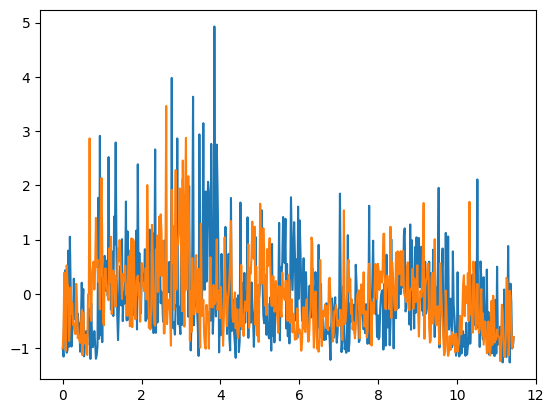

In [5]:
trial_num = 40
neural_features = data['neural_features'][trial_num].T.copy()
# Add batch dimension
neural_features = np.expand_dims(neural_features, axis=0)  # (1, C, T)
print("Neural features shape", neural_features.shape)
time = data['n_time_steps'][trial_num]
print("Duration", time * 0.02)
time = np.linspace(0, 0.02*time, time)  # seconds
sentence = data['sentence_label'][trial_num]
phonemes = data['seq_class_ids'][trial_num]

# Augmentation
# Window Zeroing
window_zeroing = False
window_zeroing_max_size = 40
window_zeroing_repetitions = 4

# Scaling
channel_scaling = True


B, C, T = neural_features.shape

plt.plot(time, neural_features[0, 300, :])


warped_features, meta = augment_time_warp_cosine_torch(
    torch.tensor(neural_features),
    dt=0.02,
    alpha=0.8,         # intensidad del warp (0<|alpha|<1)
    k=0.2,            # si None, samplea de k_range
    k_range=(0.2, 5),    # <-- aquí “la variable variable es k”
    per_channel_same_warp=True
)
neural_features = warped_features  # reemplaza o concatena como nuevo ejemplo
plt.plot(time, neural_features[0, 300, :])



if window_zeroing:
    for _ in range(window_zeroing_repetitions):
        win_len = np.random.randint(10, window_zeroing_max_size)
        start = np.random.randint(0, T - win_len)
        neural_features[ :, :, start:start + win_len] = 0

if channel_scaling:
    scaling_factors = np.random.uniform(0.7, 1.3, size=(C, 1))
    neural_features = neural_features * scaling_factors





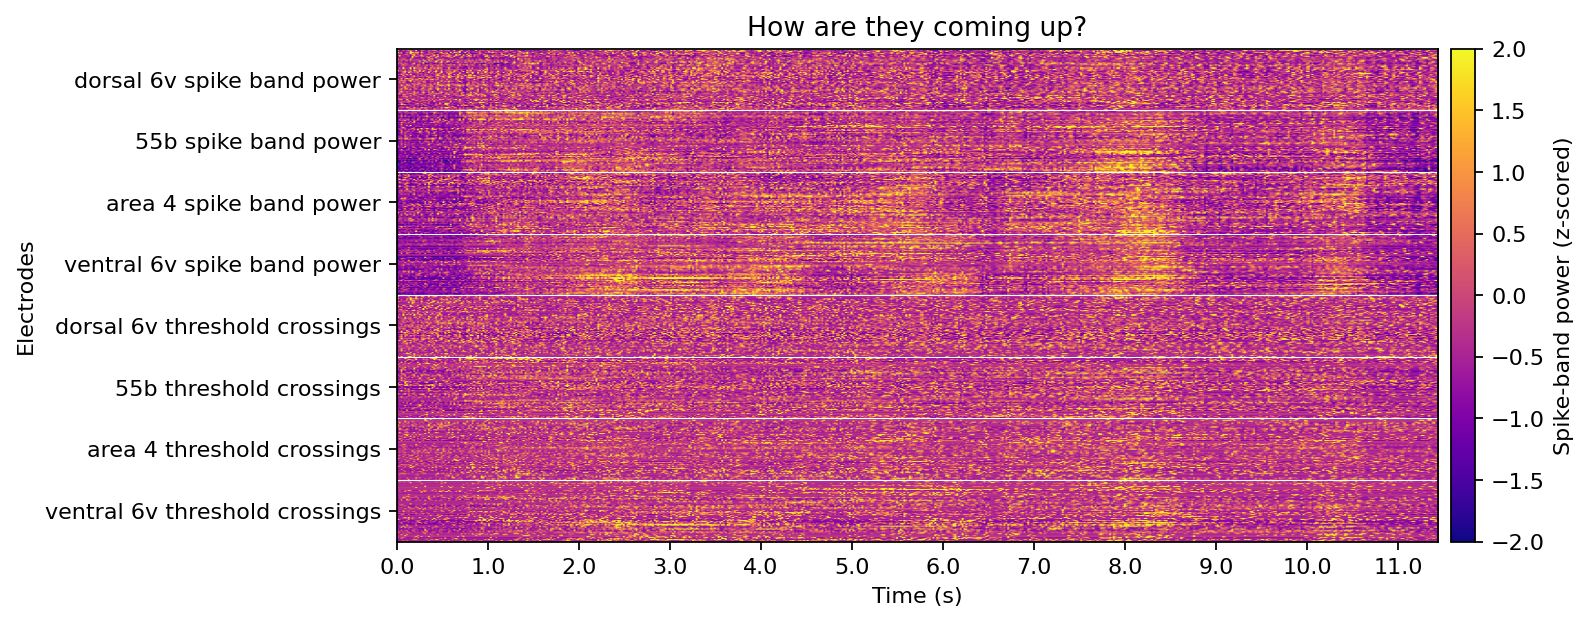

Phonemes: ['HH', 'AW', ' | ', 'AA', 'R', ' | ', 'DH', 'EY', ' | ', 'K', 'AH', 'M', 'IH', 'NG', ' | ', 'AH', 'P', ' | ']


In [6]:



# Electrode groups
groups = [
    (0, 64), (65, 128), (129, 192), (193, 256),
    (257, 320), (321, 384), (385, 448), (449, 512)
]

group_labels = [
    "ventral 6v threshold crossings",
    "area 4 threshold crossings",
    "55b threshold crossings",
    "dorsal 6v threshold crossings",
    "ventral 6v spike band power",
    "area 4 spike band power",
    "55b spike band power",
    "dorsal 6v spike band power"
]

fig, ax = plt.subplots(figsize=(10, 4), dpi=160)

# Heatmap
norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
im = ax.imshow(
    neural_features[0], aspect='auto', origin='lower',
    extent=[time[0], time[-1], 0, 512],
    cmap='plasma', norm=norm
)

# Group separators
for (start, end) in groups:
    ax.hlines(end, time[0], time[-1], color='white', linewidth=0.5)

# Y-ticks at group midpoints with labels
mid_idxs = [0.5*(s+e) for s, e in groups]
ax.set_yticks(mid_idxs)
ax.set_yticklabels(group_labels)

# X-ticks every 0.5 seconds
xticks = np.arange(time[0], time[-1] , 1)
ax.set_xticks(xticks)
ax.set_xticklabels([f"{t:.1f}" for t in xticks])

# Labels
ax.set_xlabel("Time (s)")
ax.set_ylabel("Electrodes")

# Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label("Spike-band power (z-scored)")

plt.title(sentence)

plt.show()
print("Phonemes:", [LOGIT_DICT[int(p)] for p in phonemes if LOGIT_DICT[int(p)] != 'BLANK'])


# Training Progress

In [7]:
model_list = os.listdir('model_training/trained_models/')

models = {}

for model_name in model_list:
    model_path = os.path.join('model_training/trained_models/', model_name)
    train_metrics = pd.read_csv(os.path.join(model_path, 'train_metrics.csv'))
    val_metrics = pd.read_csv(os.path.join(model_path, 'val_metrics.csv'))
    model = {
        'name': model_name,
        'train_losses': train_metrics['train_losses'],
        'val_losses': val_metrics['val_losses'],
        'val_PERs': val_metrics['val_PERs'],
    }

    models[model_name] = model




dict_keys(['baseline', 'channel_scaling', 'time_warp'])


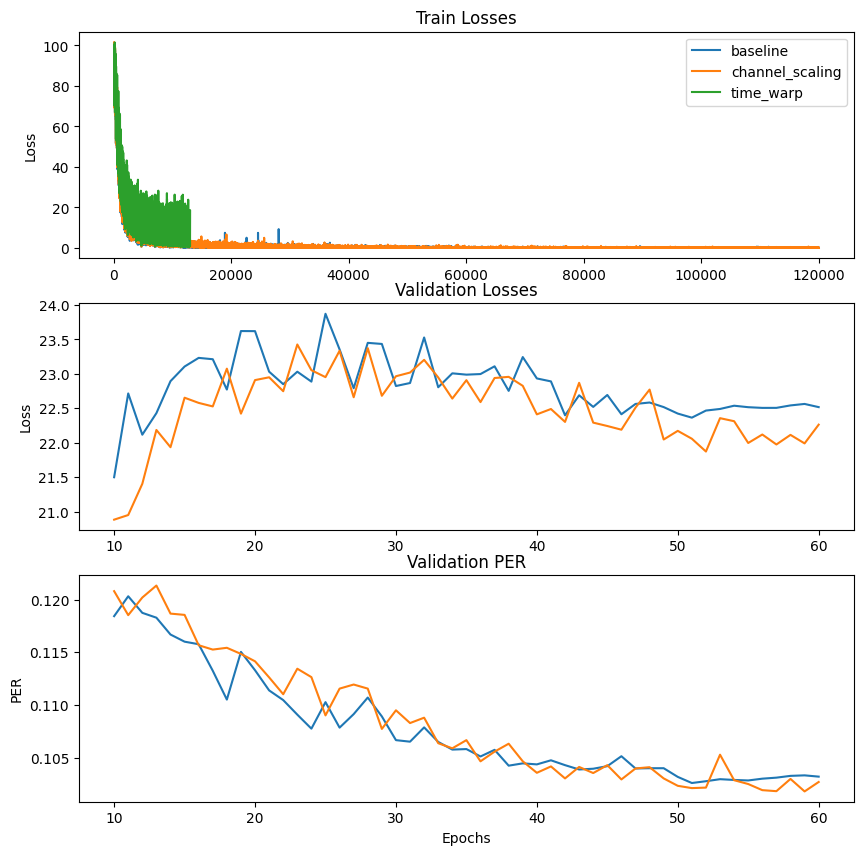

In [8]:
print(models.keys())

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for model in models:
    ax[0].plot(models[model]['train_losses'][100:], label=model)
    ax[0].set_title('Train Losses')
    ax[0].set_ylabel('Loss')

    ax[1].plot(models[model]['val_losses'][10:], label=model)
    ax[1].set_title('Validation Losses')
    ax[1].set_ylabel('Loss')

    ax[2].plot(models[model]['val_PERs'][10:], label=model)
    ax[2].set_title('Validation PER')
    ax[2].set_xlabel('Epochs')
    ax[2].set_ylabel('PER')
# add legend
ax[0].legend()

plt.show()


In [9]:
import pandas as pd

df = pd.read_csv('slurm_jobs_info.csv')
df = df[df['State'] == 'COMPLETED (exit code 0)']

# loop over rows in Memory Utilized and adjust for MB and KB
df = df[df['Memory Utilized'] != '0.00  (estimated maximum)']


for i, row in df.iterrows():
    if 'estimated' in row['Memory Utilized']:
        df.at[i, 'Memory Utilized'] = np.nan
        continue
    if 'MB' in row['Memory Utilized']:
        df.at[i, 'Memory Utilized'] = float(row['Memory Utilized'].replace('MB', '').strip()) / 1024
    if 'KB' in row['Memory Utilized']:
        df.at[i, 'Memory Utilized'] = float(row['Memory Utilized'].replace('KB', '').strip()) / (1024 * 1024)

df['Memory Utilized'] = df['Memory Utilized'].astype(float)
# remove nan accoring to Memory Utilized
df['user'] = df['User/Group'].apply(lambda x: x.split('/')[0] if '/' in x else x)
df['Unused CPU'] = df['Cores per node'] * (1- df['CPU Efficiency']/100)
df['Unused Memory'] =  df['Memory Utilized']*100/df['Memory Efficiency'] -df['Memory Utilized']
df = df.dropna(subset=['Memory Utilized', 'Memory Efficiency','Unused Memory'])
# drop inf
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Unused Memory'])

df

/tmp/ipykernel_1637102/1967066045.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Unused Memory'])


,Job ID,Cluster,User/Group,State,Nodes,Cores per node,CPU Utilized,CPU Efficiency,Job Wall-clock time,Memory Utilized,Memory Efficiency,Cores,Array Job ID,WARNING,user,Unused CPU,Unused Memory
0,70000,ihealth-cluster,bllancao/bllancao,COMPLETED (exit code 0),1.0,20.0,00:09:43,26.50,00:01:50,15.880000,15.88,NaN,NaN,NaN,bllancao,14.7000,84.120000
1,70001,ihealth-cluster,bllancao/bllancao,COMPLETED (exit code 0),1.0,20.0,00:09:35,25.44,00:01:53,14.740000,14.74,NaN,NaN,NaN,bllancao,14.9120,85.260000
2,70002,ihealth-cluster,bllancao/bllancao,COMPLETED (exit code 0),1.0,20.0,00:09:30,25.68,00:01:51,15.210000,15.21,NaN,NaN,NaN,bllancao,14.8640,84.790000
3,70003,ihealth-cluster,bllancao/bllancao,COMPLETED (exit code 0),1.0,20.0,00:09:40,26.13,00:01:51,14.390000,14.39,NaN,NaN,NaN,bllancao,14.7740,85.610000
4,70004,ihealth-cluster,bllancao/bllancao,COMPLETED (exit code 0),1.0,20.0,00:09:47,26.44,00:01:51,16.180000,16.18,NaN,NaN,NaN,bllancao,14.7120,83.820000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3882,73891,ihealth-cluster,cgvallea/cgvallea,COMPLETED (exit code 0),1.0,10.0,1-14:12:09,71.66,05:19:51,25.710000,64.28,NaN,NaN,NaN,cgvallea,2.8340,14.286889
3883,73892,ihealth-cluster,cgrivera/cgrivera,COMPLETED (exit code 0),1.0,2.0,00:01:05,77.38,00:00:42,3.180000,15.91,NaN,NaN,NaN,cgrivera,0.4524,16.807429
3889,73898,ihealth-cluster,cgrivera/cgrivera,COMPLETED (exit code 0),1.0,2.0,00:01:02,83.78,00:00:37,2.530000,12.66,NaN,NaN,NaN,cgrivera,0.3244,17.454202
3890,73899,ihealth-cluster,cgrivera/cgrivera,COMPLETED (exit code 0),1.0,2.0,00:01:17,85.56,00:00:45,2.590000,12.96,NaN,NaN,NaN,cgrivera,0.2888,17.394568


Text(0, 0.5, 'Unused CPU (cores)')

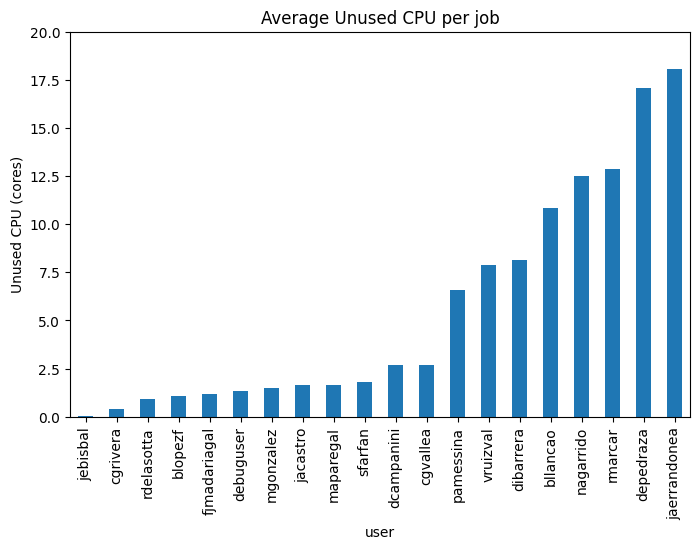

In [ ]:
df.groupby('user')['Unused CPU'].mean().sort_values().plot(kind='bar', figsize=(8,5), title='Average Unused CPU per job')
plt.ylim(0, 20)
plt.ylabel('Unused CPU (cores)')

Text(0, 0.5, 'CPU Efficiency (%)')

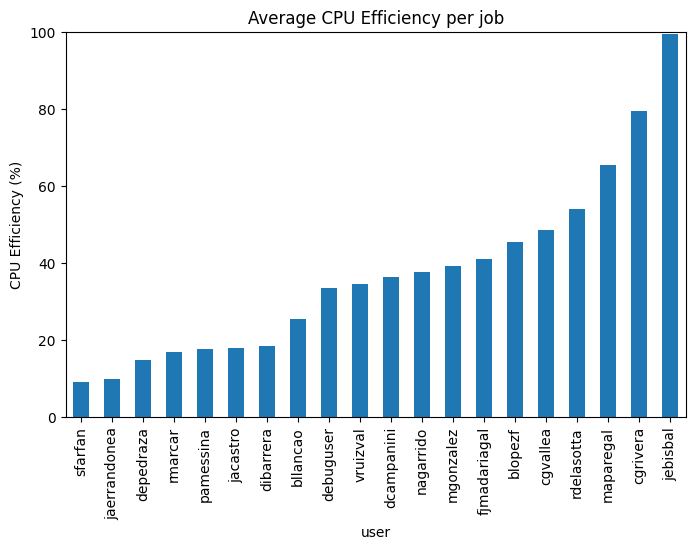

In [ ]:
df.groupby('user')['CPU Efficiency'].mean().sort_values().plot(kind='bar', figsize=(8,5), title='Average CPU Efficiency per job')
plt.ylim(0, 100)
plt.ylabel('CPU Efficiency (%)')

Text(0, 0.5, 'Memory Efficiency (%)')

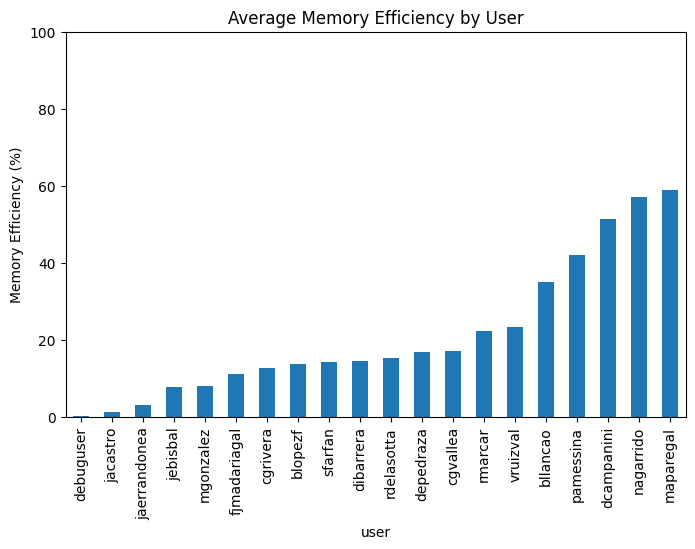

In [ ]:
df.groupby('user')['Memory Efficiency'].mean().sort_values().plot(kind='bar', figsize=(8,5), title='Average Memory Efficiency by User')
plt.ylim(0, 100)
plt.ylabel('Memory Efficiency (%)')

Text(0, 0.5, 'Unused Memory (GB)')

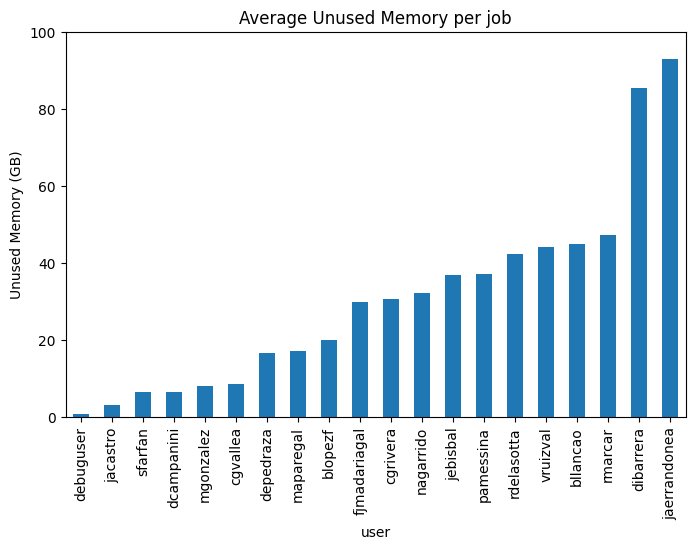

In [ ]:
df.groupby('user')['Unused Memory'].mean().sort_values().plot(kind='bar', figsize=(8,5), title='Average Unused Memory per job')
plt.ylim(0, 100)
plt.ylabel('Unused Memory (GB)')